In [1]:
import numpy as np
import pandas as pd

In [2]:
from pylab import *
from matplotlib.ticker import  MultipleLocator
from matplotlib.ticker import  FormatStrFormatter

In [3]:
df_monin_uta = pd.read_excel(r'D:\workdata\54_kz\KC_global_uta_tap_q_rv1.xlsx',sheet_name = 'monin obukhov kc uta',)
df_monin_tap = pd.read_excel(r'D:\workdata\54_kz\KC_global_uta_tap_q_rv1.xlsx',sheet_name = 'monin obukhov kc tap',)
df_monin_z = pd.read_excel(r'D:\workdata\54_kz\KC_global_uta_tap_q_rv1.xlsx',sheet_name = 'monin obukhov z',)
df_len_uta = pd.read_excel(r'D:\workdata\54_kz\KC_global_uta_tap_q_rv1.xlsx',sheet_name = 'mixing length kc uta',)
df_len_tap = pd.read_excel(r'D:\workdata\54_kz\KC_global_uta_tap_q_rv1.xlsx',sheet_name = 'mixing length kc tap',)
df_len_z = pd.read_excel(r'D:\workdata\54_kz\KC_global_uta_tap_q_rv1.xlsx',sheet_name = 'mixing length z',)

In [4]:
len_uta = np.zeros((8784,20))
for ii in range(0,8760):
    for zz in range(0,20):
        if df_len_uta.iloc[ii,zz]==-1000:
            len_uta[ii,zz] = df_monin_uta.iloc[ii,zz]
        else:
            len_uta[ii,zz] = df_len_uta.iloc[ii,zz]*3.5

In [5]:
len_tap = np.zeros((8784,20))
for ii in range(0,8760):
    for zz in range(0,20):
        if df_len_tap.iloc[ii,zz]==-1000:
            len_tap[ii,zz] = df_monin_tap.iloc[ii,zz]
        else:
            len_tap[ii,zz] = df_len_tap.iloc[ii,zz]*3.5

In [6]:
df_len_uta.iloc[:, :] = len_uta
df_len_tap.iloc[:, :] = len_tap

In [7]:
start_time = pd.Timestamp('2020-01-01 00:00:00')

df_monin_uta['datetime'] = pd.date_range(start=start_time, periods=len(df_monin_uta), freq='H')
df_monin_tap['datetime'] = pd.date_range(start=start_time, periods=len(df_monin_tap), freq='H')
df_len_uta['datetime'] = pd.date_range(start=start_time, periods=len(df_len_uta), freq='H')
df_len_tap['datetime'] = pd.date_range(start=start_time, periods=len(df_len_tap), freq='H')

df_monin_uta.set_index('datetime', inplace=True)
df_monin_tap.set_index('datetime', inplace=True)
df_len_uta.set_index('datetime', inplace=True)
df_len_tap.set_index('datetime', inplace=True)

df_monin_uta_monthly_mean = df_monin_uta.resample('M').mean()
df_monin_tap_monthly_mean = df_monin_tap.resample('M').mean()
df_len_uta_monthly_mean = df_len_uta.resample('M').mean()
df_len_tap_monthly_mean = df_len_tap.resample('M').mean()


In [8]:


# 提取小时，并按小时分组求平均
df_monin_uta_hourly_avg = df_monin_uta.groupby(df_monin_uta.index.hour).mean()
df_monin_tap_hourly_avg = df_monin_tap.groupby(df_monin_tap.index.hour).mean()
df_len_uta_hourly_avg = df_len_uta.groupby(df_len_uta.index.hour).mean()
df_len_tap_hourly_avg = df_len_tap.groupby(df_len_tap.index.hour).mean()

In [9]:
from matplotlib.colors import BoundaryNorm  # 新增导入
import matplotlib.colors as colors

In [10]:
#colorslist = ['#0024ff','#0089ff','#00eeff','#00ffaa','#85ff00','#dfff00','#ffa300','#ff6b00','#ff1100']
colorslist = ['#13457E','#2C76AC','#69A5C7','#AED0E1','#E4ECF3','#FFFFFF','#F9E8DE','#DB7C64','#DB7C64','#BB3A3C','#841925']
cmap = colors.LinearSegmentedColormap.from_list('mylist',colorslist,N=9*20)
cn = 2
zz = np.array([0.5,0.6,0.7,0.8,0.9,1.1,1.2,1.3,1.4,1.5,])
zz_uta=zz
aa = np.linspace(zz[0], zz[1], num=cn)
bb = np.linspace(zz[1], zz[2], num=cn)
cc = np.linspace(zz[2], zz[3], num=cn)
dd = np.linspace(zz[3], zz[4], num=cn)
ee = np.linspace(zz[4], zz[5], num=cn)
ff = np.linspace(zz[5], zz[6], num=cn)
gg = np.linspace(zz[6], zz[7], num=cn)
hh = np.linspace(zz[7], zz[8], num=cn)
ii = np.linspace(zz[8], zz[9], num=cn)
bounds_uta = concatenate((aa[:-1],bb[:-1],cc[:-1],dd[:-1],ee[:-1],ff[:-1],gg[:-1],hh[:-1],ii[:]),axis=0)
# change to ton
norm_uta = colors.BoundaryNorm(bounds_uta, cmap.N)
   # pcm = fig_ax1.pcolor(lon, lat,var,cmap=cmap,norm = norm,transform=ccrs.PlateCarree(),alpha=0.6)

In [11]:
from matplotlib.colors import BoundaryNorm  # 新增导入
import matplotlib.colors as colors

In [12]:
#colorslist = ['#0024ff','#0089ff','#00eeff','#00ffaa','#85ff00','#dfff00','#ffa300','#ff6b00','#ff1100']
'''
colorslist = [
    "#388E3C",  # 森林绿
    "#7CB342",  # 青苹果绿
    "#AED581",  # 青草绿
    "#D4E157",  # 浅绿黄
    "#F1C40F",  # 鲜黄
    "#F39C12",  # 橙黄
    "#E74C3C",  # 番茄红
    "#C0392B",  # 深红
    ]
'''
colorslist = ['#13457E','#2C76AC','#69A5C7','#AED0E1','#E4ECF3','#FFFFFF','#F9E8DE','#DB7C64','#DB7C64','#BB3A3C','#841925']


cmap = colors.LinearSegmentedColormap.from_list('mylist',colorslist,N=9*2)
cn = 2
zz = np.array([0.01,0.033,0.1,0.33,0.9,1.1,3,10,30,100,])
zz_uta=zz
aa = np.linspace(zz[0], zz[1], num=cn)
bb = np.linspace(zz[1], zz[2], num=cn)
cc = np.linspace(zz[2], zz[3], num=cn)
dd = np.linspace(zz[3], zz[4], num=cn)
ee = np.linspace(zz[4], zz[5], num=cn)
ff = np.linspace(zz[5], zz[6], num=cn)
gg = np.linspace(zz[6], zz[7], num=cn)
hh = np.linspace(zz[7], zz[8], num=cn)
ii = np.linspace(zz[8], zz[9], num=cn)
bounds_uta = concatenate((aa[:-1],bb[:-1],cc[:-1],dd[:-1],ee[:-1],ff[:-1],gg[:-1],hh[:-1],ii[:]),axis=0)
# change to ton
norm_uta = colors.BoundaryNorm(bounds_uta, cmap.N)
   # pcm = fig_ax1.pcolor(lon, lat,var,cmap=cmap,norm = norm,transform=ccrs.PlateCarree(),alpha=0.6)

In [13]:
p1 = np.zeros((24,20))
p1[17:] = df_len_uta_hourly_avg[0:7]
p1[:17] = df_len_uta_hourly_avg[7:]

p2 = np.zeros((24,20))
p2[17:] = df_monin_uta_hourly_avg[0:7]
p2[:17] = df_monin_uta_hourly_avg[7:]

p3 = np.zeros((24,20))
p3[:9] = df_len_tap_hourly_avg[15:]
p3[9:] = df_len_tap_hourly_avg[:15]

p4 = np.zeros((24,20))
p4[:9] = df_monin_tap_hourly_avg[15:]
p4[9:] = df_monin_tap_hourly_avg[:15]


C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_22052\816915690.py:20: RuntimeWarning: divide by zero encountered in divide
  p1.T/p2.T,
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_22052\816915690.py:20: RuntimeWarning: invalid value encountered in divide
  p1.T/p2.T,
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_22052\816915690.py:43: RuntimeWarning: divide by zero encountered in divide
  p3.T/p4.T,
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_22052\816915690.py:43: RuntimeWarning: invalid value encountered in divide
  p3.T/p4.T,


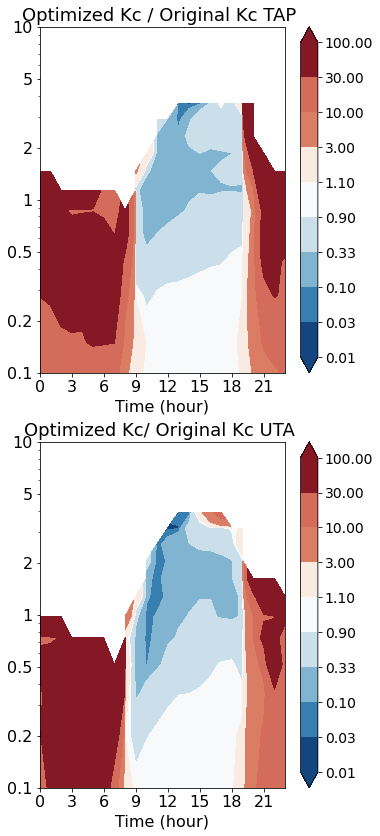

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 创建子图
variables = ('0','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23')
xv = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])
xv2 = np.array([1.5, 4.5, 7.5, 10.5, 13.5, 16.5, 19.5, 22.5])




# 创建子图
fig, ax = plt.subplots(2, 1, figsize=(5.5, 14))
# TAP 图

c1 = ax[1].contourf(
    xv,
    df_len_z['mixing length uta z'].values/1000,
    p1.T/p2.T,
    cmap=cmap,
    norm=norm_uta,  # 使用BoundaryNorm
    levels=zz_uta, 
    extend='both' ,
)
ax[1].set_title('Optimized Kc/ Original Kc UTA ', fontsize=18)
ax[1].set_xlabel('Time (hour)', fontsize=16)
#ax[0].set_ylabel('Altitude above ground (km)', fontsize=16)
ax[1].set_xticks(xv)
ax[1].set_xticklabels(variables, fontsize=16)
ax[1].set_yscale('log')
ax[1].set_ylim(0.1, 10)
ax[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
c1_cb = fig.colorbar(c1, ax=ax[1], orientation='vertical', extend='both')
c1_cb.ax.tick_params(labelsize=14)
ax[1].set_xticks(np.arange(0, 23, 3))  # 设置横坐标刻度间隔为3小时
ax[1].tick_params(axis='x', labelsize=16)
ax[1].tick_params(axis='y', labelsize=14)
#-----------------------------------------------------------------------------------------------------------------------------------------
c4 = ax[0].contourf(
    xv,
    df_monin_z['monin obukhov tap z'].values/1000,
    p3.T/p4.T,
    cmap=cmap,
    norm=norm_uta,  # 使用BoundaryNorm
    levels=zz_uta, 
    extend='both' ,
)
ax[0].set_title('Optimized Kc / Original Kc TAP ', fontsize=18)
ax[0].set_xlabel('Time (hour)', fontsize=16)
#ax[0].set_ylabel('Altitude above ground (km)', fontsize=16)
ax[0].set_xticks(xv)
ax[0].set_xticklabels(variables, fontsize=16)
ax[0].set_yscale('log')
ax[0].set_ylim(0.1, 10)
ax[0].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
c4_cb = fig.colorbar(c4, ax=ax[0], orientation='vertical', extend='both')
c4_cb.ax.tick_params(labelsize=14)
ax[0].set_xticks(np.arange(0, 23, 3))  # 设置横坐标刻度间隔为3小时
ax[0].tick_params(axis='x', labelsize=16)
ax[0].tick_params(axis='y', labelsize=14)
#ax[0].text(12.5,11.4,'ppm',fontsize=14)


c1_cb.ax.tick_params(labelsize=14)
c4_cb.ax.tick_params(labelsize=14)



ax[1].set_ylim(0.1, 10)  # 设置对数坐标的显示范围为 0.01 km 到 10 km
ax[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=10))
ax[1].set_yscale('log')



yticks_positions = [0.1, 0.2, 0.5, 1, 2, 5,10]
yticks_labels = ['0.1', '0.2', '0.5', '1', '2', '5','10' ]
ax[1].set_yticks(yticks_positions)
ax[1].set_yticklabels(yticks_labels, fontsize=16)
ax[0].set_yticks(yticks_positions)
ax[0].set_yticklabels(yticks_labels, fontsize=16)




# 图像分辨率
plt.rcParams['savefig.dpi'] = 500

#plt.savefig(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\论文用图v5\Kc_hour_div4.png', bbox_inches='tight')



